<a href="https://colab.research.google.com/github/gabyx7677/proyectos_generales/blob/main/Proyecto_Sprint_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

Es necesario primeramente visualizar los datos y ver como se componen

In [ ]:
# importar librerías
import pandas as pd

In [ ]:
# leer conjuntos de datos en los DataFrames
archivos = ['/content/aisles.csv', '/content/departments.csv', '/content/instacart_orders.csv', '/content/order_products.csv', '/content/products.csv']
dfs = [pd.read_csv(csv, sep = ';') for csv in archivos]

# Acceso a cada DataFrame por separado
df_aisles, df_departments, df_instacart_orders, df_order_products, df_products = dfs

In [ ]:
# mostrar información del DataFrame
df_aisles

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
...,...,...
129,130,hot cereal pancake mixes
130,131,dry pasta
131,132,beauty
132,133,muscles joints pain relief


In [ ]:
# mostrar información del DataFrame
df_departments

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [ ]:
# mostrar información del DataFrame
df_instacart_orders

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


In [ ]:
# mostrar información del DataFrame
df_order_products

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1
...,...,...,...,...
4545002,577211,15290,12.0,1
4545003,1219554,21914,9.0,0
4545004,692640,47766,4.0,1
4545005,319435,691,8.0,1


In [ ]:
# mostrar información del DataFrame
df_products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Conclusiones</strong>

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.


El conjunto de datos está bien estructurado para analizar el comportamiento de compra de los usuarios en Instacart, combinando información temporal (pedido, hora, días entre pedidos) con detalles de productos (categorías, departamentos) y patrones de compra (reordenados, orden en el carrito). Esto permite no solo entender cuándo y qué compran los clientes, sino también identificar tendencias de repetición y preferencias por categorías, lo que es clave para diseñar estrategias de recomendación y optimización logística.
</div>

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Plan de solución</strong>

En esta etapa se realizará el preprocesamiento de los datos. Primero, se inspeccionarán los DataFrames para entender su estructura general, verificar el número de filas y columnas, y revisar los tipos de datos presentes. Luego, se eliminarán las filas duplicadas que puedan distorsionar el análisis. Se analizarán las columnas para detectar valores nulos, y se decidirá si deben eliminarse o rellenarse con un valor apropiado. También se validarán y corregirán los tipos de datos, asegurando que fechas, números y categorías estén correctamente definidos. Se revisarán los valores únicos, estadísticas básicas y posibles outliers para cada variable relevante. Finalmente, se renombrarán las columnas si es necesario para facilitar su manejo, y se guardará una copia limpia del conjunto de datos para su posterior análisis.
</div>

In [ ]:
# Se verifica con el método info las estructuras de los data frames

print(df_aisles.info(), df_departments.info(), df_instacart_orders.info(), df_order_products.info(), df_products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [ ]:
# Revisa si hay pedidos duplicados, keep = False incluye la primera aparición de los duplicados
print(df_instacart_orders.duplicated(keep=False).sum())
print(df_instacart_orders.duplicated(subset='order_id', keep=False).sum()) # Si este se repite significa que el pedido está repetido, lo cual es malo
print(df_instacart_orders.duplicated(subset='user_id', keep=False).sum()) # Si este se repite solo significa que el mismo usuario hace varios pedidos
df_instacart_orders.duplicated() # Saca la serie booleana si es duplicado o no

30
30
423612


,0
0,False
1,False
2,False
3,False
4,False
...,...
478962,False
478963,False
478964,False
478965,False


In [ ]:
type(df_instacart_orders.duplicated())

pandas.core.series.Series

In [ ]:
df_instacart_orders.loc[df_instacart_orders.duplicated(keep=False) == True] # Saca el df_instacart_orders solo por los indices duplicados

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
30371,1918001,188546,14,3,2,16.0
99462,794638,50898,24,3,2,2.0
119251,408114,68324,4,3,2,18.0
142258,2845099,31189,11,3,2,7.0
145574,794638,50898,24,3,2,2.0
164581,1112182,202304,84,3,2,6.0
200059,1782114,106752,1,3,2,NaN
204042,2125197,14050,48,3,2,3.0
215294,2160484,107525,16,3,2,30.0
223105,2160484,107525,16,3,2,30.0


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?</strong>

Todas las filas duplicadas (pedidos duplicados) son los miercoles a las 2 am
</div>

In [ ]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00, metodo "loc" me deja poner condiciones
df_ico_miercoles_2am = df_instacart_orders.loc[(df_instacart_orders['order_hour_of_day'] == 2) & (df_instacart_orders['order_dow'] == 3)]
print(df_ico_miercoles_2am.duplicated(keep=False).sum()) # Verifica si dentro del data frame de solo miercoles a las 2:00 am hay duplicados
                                                         # Efectivamente los hay porque a este punto no se han tratado
df_ico_miercoles_2am

30


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>¿Qué sugiere este resultado?</strong>

Que es necesario eliminar los pedidos duplicados, es decir, que se repita el ID de la orden es incorrecto porque representa que hay pedidos repetidos lo cual altera el análisis.
</div>

In [ ]:
# Elimina los pedidos duplicados
df_instacart_orders.drop_duplicates(inplace=True) # Se guarda en el dataframe original con el inplace=True

In [ ]:
# Vuelve a verificar si hay filas duplicadas
print(df_instacart_orders.duplicated(keep=False).sum())

0


In [ ]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print(df_instacart_orders.duplicated(subset='order_id', keep=False).sum()) # Acá ya se quitaron lo pedidos duplicados (ID orden duplicado)
print(df_instacart_orders.duplicated(subset='user_id', keep=False).sum()) # Los usuarios se pueden repetir porque son pedidos distintos

0
423595


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos</strong>

Descubrí durante el análisis previo que hay duplicados y valores nulos en el df_instacart_orders que pueden alterar su posterior manipulación, noté que los duplicados todos eran los días miercoles a las 2 am...
</div>

### `products` data frame

In [ ]:
# Verifica si hay filas totalmente duplicadas
print(df_products.duplicated(keep=False).sum())

0


In [ ]:
# Revisa únicamente si hay ID de productos duplicados
print(df_products.duplicated(subset='product_id', keep=False).sum()) # Se filtra y se verifica que no hay IDs de productos repetidos

0


In [ ]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
df_products['product_name'] = df_products['product_name'].str.upper()
print(df_products.duplicated(subset='product_name', keep=False).sum()) # Se filtra y se verifica que efectivamente hay nombres de productos repetidos

1465


In [ ]:
# Revisa si hay nombres duplicados de productos no faltantes
"""
Con el siguiente filtrado se busca con el parametro "loc" generar un df nuevo con base en el df_products
dada la condición de la serie df_products.duplicated(subset='product_name', keep=False) con la intención
de buscar si hay productos faltantes o no en la serie de product_name, efectivamente hay valores nulos
"""
df_products.loc[df_products.duplicated(subset='product_name', keep=False)].sort_values(by='product_name') # sort_values organiza alfabéticamente

,product_id,product_name,aisle_id,department_id
23339,23340,18-IN-1 HEMP PEPPERMINT PURE-CASTILE SOAP,25,11
31844,31845,18-IN-1 HEMP PEPPERMINT PURE-CASTILE SOAP,25,11
19941,19942,AGED BALSAMIC VINEGAR OF MODENA,19,13
13152,13153,AGED BALSAMIC VINEGAR OF MODENA,19,13
24830,24831,ALBACORE SOLID WHITE TUNA IN WATER,95,15
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

El análisis preliminar del df_prducts mostró que no tiene duplicados explicitos ni duplicados implicitos en la serie "product_id", lo cual a priori es bueno porque quiere decir que no hay productos repetidos, sin embargo al analisar la serie "product_name" se ve que hay nombres que si están repetidos, lo que significa que hay nombres de productos que si bien son el mismo producto tienen diferentes IDs dado el cruce de información, existen tambien duplicados NaN en la serie "product_name", lo cual es una ausencia importante porque no se sabe que producto es.
</div>

### `departments` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
print(df_departments.duplicated(keep=False).sum())

0


In [ ]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(df_departments.duplicated(subset='department_id', keep=False).sum())

0


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Se observa que no hay filas duplicadas lo cual significa que cada departamento tiene su propio ID relacionado lo cual es bueno al permitir saber la infromación real de los departamentos relacionados a los pedidos, que no haya duplicados significa que se permite un buen análisis de los datos.
</div>

### `aisles` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
print(df_aisles.duplicated(keep=False).sum())

0


In [ ]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(df_aisles.duplicated(subset='aisle_id', keep=False).sum())

0


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Se observa que no hay filas duplicadas lo cual significa que cada pasillo tiene su propio ID relacionado lo cual es bueno al permitir saber la información real de los pasillos relacionados al supermercado, que no haya duplicados significa que se permite un buen análisis de los datos.
</div>

### `order_products` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
print(df_order_products.duplicated(keep=False).sum())

0


In [ ]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso REVISAR <---------------------------------
print(df_order_products.duplicated(subset=['order_id', 'product_id'], keep=False).sum())

0


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Ya que no hay ordenes de prodcutos repetidas significa que el análisis a priori de los pedidos realizados garantizaría resultados coherentes ya que está bien seccionado por pedido y no se repite, que no haya duplicados significa que se permite un buen análisis de los datos.
</div>

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [ ]:
# Encuentra los valores ausentes en la columna 'product_name'
df_products.isna().sum()

,0
product_id,0
product_name,1258
aisle_id,0
department_id,0


In [ ]:
df_products.isna() #Se verifica el df booleano de los valores NaN

,product_id,product_name,aisle_id,department_id
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
49689,False,False,False,False
49690,False,False,False,False
49691,False,False,False,False
49692,False,False,False,False


In [ ]:
df_products.loc[df_products.isna()['product_name'] == True] # Se saca el df de los valores nulos en la columna product_name

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21





<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

los valores NaN en product_name son una serie de 1258 valores, son en el pasillo con ID 100 y el departamento con id 21
</div>

In [ ]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
df_products.loc[df_products['aisle_id'] == 100] # Efectivamente todos los vlaores ausentes de product_name están en el pasillo ID 100
                                                # Los df filttrados son del mismo tamaño

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21




<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Se identificaron 1258 productos con valores faltantes en product_name, todos ubicados en el pasillo con ID 100 y el departamento con ID 21. Dado que no aportan información relevante para el análisis y están concentrados en una sola categoría, se decidió excluirlos del conjunto de datos.
</div>

In [ ]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
df_products.loc[df_products['department_id'] == 21] # Si, todos los valores ausentes de product_name estan relacionando al ID 21 department
                                                    # Los df filttrados son del mismo tamaño

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Se identificaron 1258 productos con valores faltantes en product_name, todos ubicados en el pasillo con ID 100 y el departamento con ID 21. Dado que no aportan información relevante para el análisis y están concentrados en una sola categoría, se decidió excluirlos del conjunto de datos.
</div>

In [ ]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
df_aisles[df_aisles['aisle_id'] == 100]

,aisle_id,aisle
99,100,missing


In [ ]:
df_departments[df_departments['department_id'] == 21]

,department_id,department
20,21,missing


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Ya que aparecen como "missing" tanto en el departamento como en la categoría de pasillo quiere decir que es informaición que puede NO ser tenida en cuenta.
</div>

In [ ]:
# Completa los nombres de productos ausentes con 'Unknown'
df_products['product_name'].fillna('Unknown')

,product_name
0,CHOCOLATE SANDWICH COOKIES
1,ALL-SEASONS SALT
2,ROBUST GOLDEN UNSWEETENED OOLONG TEA
3,SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...
4,GREEN CHILE ANYTIME SAUCE
...,...
49689,HIGH PERFORMANCE ENERGY DRINK
49690,ORIGINAL PANCAKE & WAFFLE MIX
49691,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
49692,SPRING WATER BODY WASH


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Rellenando estos datos nos permite saber de manera veráz que el nombre del producto es desconocido, es mucho mas organizado y acota la información.

Un beneficio claro de reemplazar un NaN por "Unknown" es que mantienes la fila en el análisis sin perder estructura ni información asociada (como el product_id, aisle_id, etc.), mientras evitas errores o complicaciones al procesar datos faltantes.

Por ejemplo:

Algunas funciones (como groupby, value_counts, visualizaciones) no manejan bien los NaN o los ignoran por completo.

Con "Unknown" puedes contar, agrupar o etiquetar esos productos como una categoría válida sin que se pierdan del análisis.
</div>

### `orders` data frame

In [ ]:
# Encuentra los valores ausentes
df_instacart_orders.isna().sum()

,0
order_id,0
user_id,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,28817


In [ ]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
df_instacart_orders.loc[df_instacart_orders['days_since_prior_order'].isna() == True] # No, no hay mas valores ausentes

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Que no haya otro valor repetido más que los datos de la columna days_since_prior_order deja ver que los datos están organizados y las ordenes no se repiten.
</div>

### `order_products` data frame

In [ ]:
# Encuentra los valores ausentes
df_order_products.isna().sum()

,0
order_id,0
product_id,0
add_to_cart_order,836
reordered,0


In [ ]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
df_order_products['add_to_cart_order'].describe()

,add_to_cart_order
count,4.544171e+06
mean,8.351669e+00
std,7.080368e+00
min,1.000000e+00
25%,3.000000e+00
50%,6.000000e+00
75%,1.100000e+01
max,6.400000e+01


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Que no haya otro valor repetido más que los datos de la columna days_since_prior_order deja ver que los datos están organizados y las ordenes no se repiten, el filtrado final muestra que se hicieron un máximo de 64 y un valor minimo de 1.
</div>

In [ ]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
df_order_products.loc[df_order_products['add_to_cart_order'].isna() == True]['order_id']

,order_id
737,2449164
9926,1968313
14394,2926893
16418,1717990
30114,1959075
...,...
4505662,1800005
4511400,1633337
4517562,404157
4534112,1673227


In [ ]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
df_order_products.loc[df_order_products['add_to_cart_order'].isna() == True].groupby('order_id')['product_id'].count().describe()


,product_id
count,70.000000
mean,11.942857
std,12.898585
min,1.000000
25%,3.000000
50%,7.000000
75%,14.000000
max,63.000000


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

Con el filtrado anterior se muestra que el menor numero de productos solictados en los valores ausentes de add_to_cart_order es de 1 y el maximo de 63
</div>

In [ ]:
# Remplaza los valores ausentes en la columna 'add_to_cart con 999 y convierte la columna al tipo entero.
df_order_products['add_to_cart_order'].fillna(999, inplace=True)
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].astype('int')
df_order_products['add_to_cart_order'].loc[df_order_products['add_to_cart_order'] == 999]

<ipython-input-130-f50cfe39cf20>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_order_products['add_to_cart_order'].fillna(999, inplace=True)


,add_to_cart_order
737,999
9926,999
14394,999
16418,999
30114,999
...,...
4505662,999
4511400,999
4517562,999
4534112,999


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Describe brevemente tus hallazgos y lo que hiciste con ellos.</strong>

El cambio de valores nulos por el entero '999':

-Evitas nulos en análisis numéricos o modelos ML:
Muchos algoritmos de machine learning y funciones estadísticas no manejan bien los NaN (valores nulos). Al poner 999, garantizas que la columna siga siendo de tipo entero, lo que simplifica el procesamiento.

-Sirve como marcador explícito de "desconocido/tardío":
Puedes interpretarlo como un valor artificial que indica que el orden no está disponible o es muy posterior al resto (lo cual puede tener sentido si 999 está muy lejos del rango típico).

-Simplifica filtros o transformaciones:
Puedes fácilmente filtrar los productos con add_to_cart_order == 999 si necesitas tratarlos como una categoría especial.
</div>




<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Conclusiones</strong>
Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

En el Paso 2 se llevó a cabo un preprocesamiento exhaustivo de los datos con el objetivo de garantizar su calidad, consistencia y utilidad para el análisis posterior. Se identificaron y gestionaron valores nulos de forma contextual, imputándolos o eliminándolos según correspondiera, y se corrigieron tipos de datos para asegurar coherencia en el tratamiento de la información. Además, se eliminaron duplicados y se normalizaron los nombres de columnas para facilitar su manipulación. Se reorganizaron datos para optimizar la estructura del conjunto, lo que incluyó la creación de nuevas variables, la transformación de columnas existentes y la segmentación de información en categorías relevantes. También se manejaron valores atípicos y se tomaron decisiones específicas para representar adecuadamente la ausencia de datos, sin comprometer la integridad del conjunto. En algunos casos este proceso permitió dejar una base de datos limpia, estructurada y lista para la exploración, garantizando que los análisis posteriores se realicen sobre datos consistentes y confiables.
</div>

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

In [ ]:
df_instacart_orders.head()


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


### [A1] Verifica que los valores sean sensibles

In [ ]:
df_instacart_orders['order_hour_of_day'].describe() # Son congruentes los valores ya que las horas del día oscilan entre 0 y 23

,order_hour_of_day
count,478952.000000
mean,13.447034
std,4.224567
min,0.000000
25%,10.000000
50%,13.000000
75%,16.000000
max,23.000000


In [ ]:
df_instacart_orders['order_dow'].describe() # Son congruentes los valores ya que los días de la semana oscilan entre 0 y 6

,order_dow
count,478952.000000
mean,2.775051
std,2.045901
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,6.000000







<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

Los valores tienen una congruencia ya que están acotados a valores reales que representan horas y días.
</div>

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

In [ ]:
df_instacart_orders['order_hour_of_day'].value_counts()

,count
order_hour_of_day,
10,40578
11,40032
15,39789
14,39631
13,39007
16,38112
12,38034
9,35896
17,31930


In [ ]:
orders_by_hour = df_instacart_orders['order_hour_of_day'].value_counts().sort_index()
orders_by_hour

,count
order_hour_of_day,
0,3180
1,1763
2,989
3,770
4,765
5,1371
6,4215
7,13043
8,25024


<ipython-input-136-63d2553d40d2>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_by_hour.index, y=orders_by_hour.values, palette="viridis")


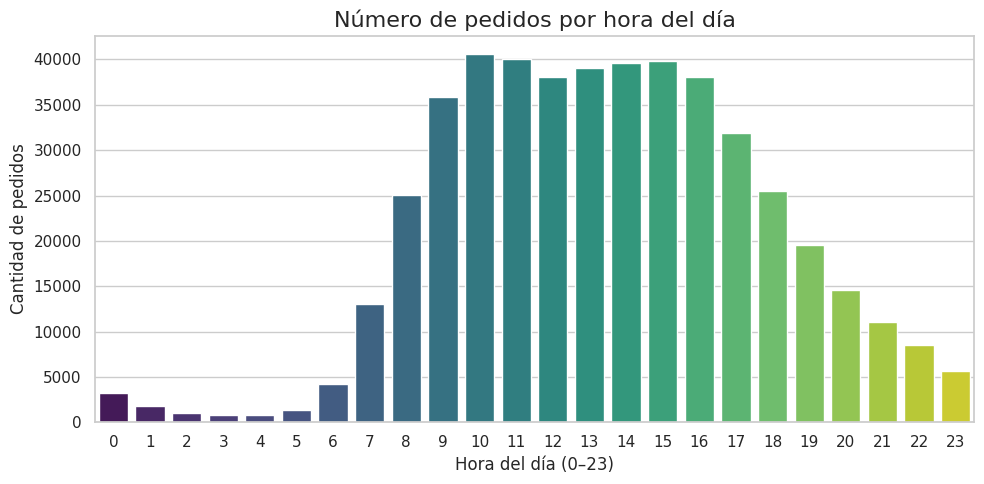

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set(style="whitegrid")

# Crear el gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=orders_by_hour.index, y=orders_by_hour.values, palette="viridis")

# Etiquetas y título
plt.title("Número de pedidos por hora del día", fontsize=16)
plt.xlabel("Hora del día (0–23)")
plt.ylabel("Cantidad de pedidos")
plt.xticks(range(0, 24))  # asegúrate de que muestre todas las horas
plt.tight_layout()
plt.show()

<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

La mayor cantidad de pedidos se realizan a las 10 am
</div>

### [A3] ¿Qué día de la semana compran víveres las personas?

In [ ]:
orders_by_dow = df_instacart_orders['order_dow'].value_counts().sort_index()
orders_by_dow


,count
order_dow,
0,84090
1,82185
2,65833
3,60897
4,59810
5,63488
6,62649


<ipython-input-138-f0aceb0c8a3b>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_by_dow.index, y=orders_by_dow.values, palette="rocket")


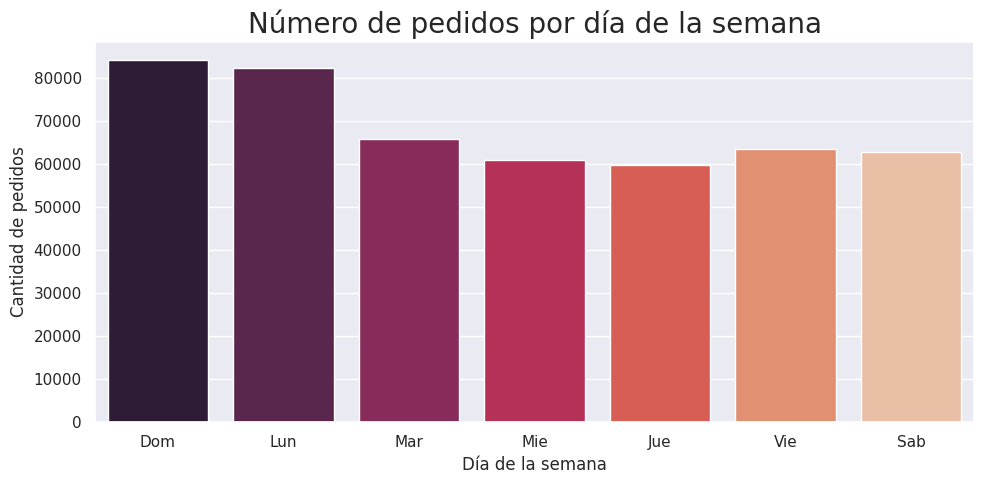

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

dow = ["Dom", "Lun", "Mar", "Mie", "Jue", "Vie", "Sab"]
orders_by_dow.index = dow
# Estilo
sns.set(style="darkgrid")

# Crear el gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=orders_by_dow.index, y=orders_by_dow.values, palette="rocket")

# Etiquetas y título
plt.title("Número de pedidos por día de la semana", fontsize=20)
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de pedidos")
plt.xticks(range(0, 7))  # asegúrate de que muestre todas las horas
plt.tight_layout()
plt.show()

<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

El día que mas compran víveres las personas es el día domingo

</div>

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

In [ ]:
df_instacart_orders['days_since_prior_order'].describe()

,days_since_prior_order
count,450135.000000
mean,11.101814
std,9.190004
min,0.000000
25%,4.000000
50%,7.000000
75%,15.000000
max,30.000000


In [ ]:
days_since_first_order = df_instacart_orders['days_since_prior_order'].value_counts()
days_since_first_order

,count
days_since_prior_order,
30.0,51337
7.0,44577
6.0,33930
4.0,31006
3.0,30224
5.0,30096
2.0,27138
8.0,25361
1.0,20179


<ipython-input-141-991860d56790>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=days_since_first_order.index, y=days_since_first_order.values, palette="mako")


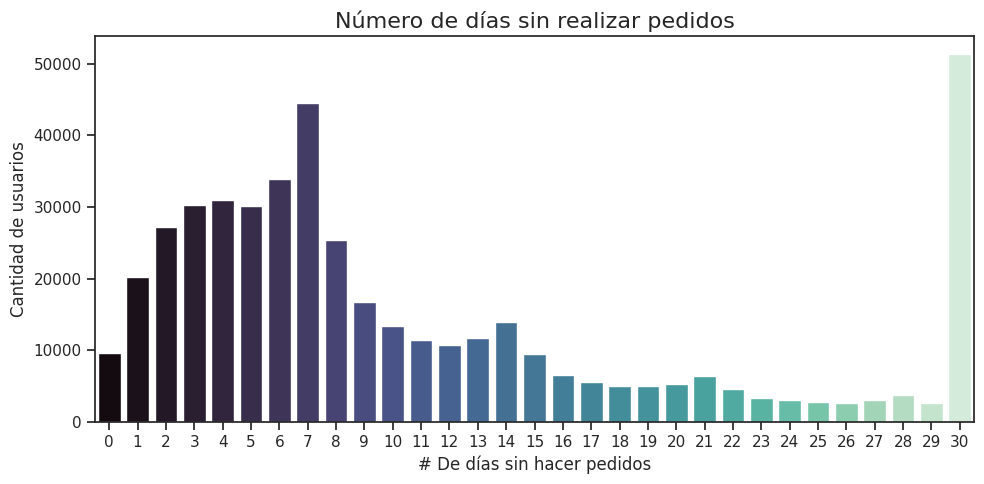

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

days_since_first_order.index = days_since_first_order.index.astype(int)

# Estilo
sns.set(style="ticks")

# Crear el gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=days_since_first_order.index, y=days_since_first_order.values, palette="mako")

# Etiquetas y título
plt.title("Número de días sin realizar pedidos", fontsize=16)
plt.xlabel("# De días sin hacer pedidos")
plt.ylabel("Cantidad de usuarios")
plt.tight_layout()
plt.show()

<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

Los valores tienen una congruencia ya que están acotados a valores reales que representan horas y días, lo minimo que tardan en hacer otro pedido es de 0 días, hay usuarios con 30 días o más sin hacer pedidos.
</div>

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [ ]:
orders_per_hour_wed = df_instacart_orders.loc[df_instacart_orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
orders_per_hour_wed # Distribución por horas de ordenes de pedidos los días miercoles

,count
order_hour_of_day,
0,373
1,215
2,106
3,101
4,108
5,170
6,643
7,1732
8,3125


<ipython-input-143-e53cfe007801>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_per_hour_wed.index, y=orders_per_hour_wed.values, palette="flare")


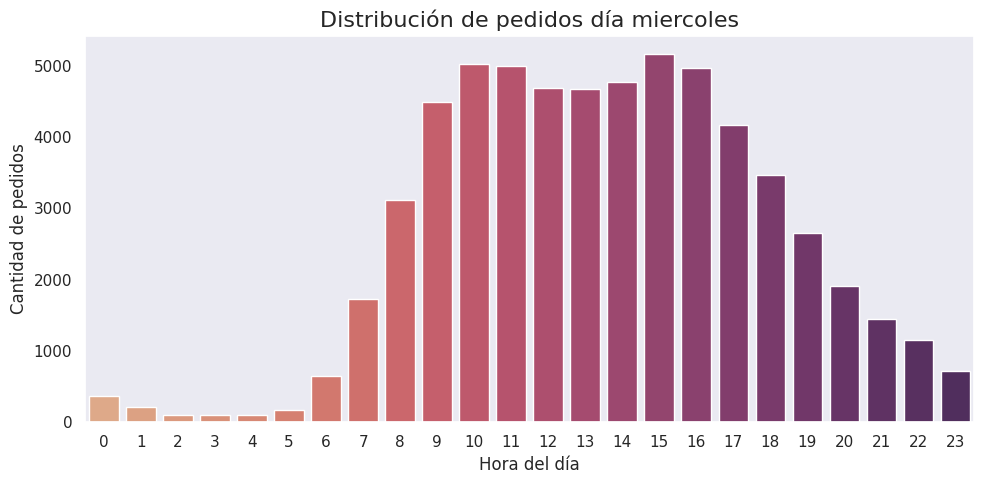

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set(style="dark")

# Crear el gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=orders_per_hour_wed.index, y=orders_per_hour_wed.values, palette="flare")

# Etiquetas y título
plt.title("Distribución de pedidos día miercoles", fontsize=16)
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de pedidos")
plt.tight_layout()
plt.show()

In [ ]:
orders_per_hour_sat = df_instacart_orders.loc[df_instacart_orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()
orders_per_hour_sat # Distribución por horas de ordenes de pedidos los días sábados

,count
order_hour_of_day,
0,464
1,254
2,177
3,125
4,118
5,161
6,451
7,1619
8,3246


<ipython-input-145-38c55384df22>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_per_hour_sat.index, y=orders_per_hour_sat.values, palette="crest")


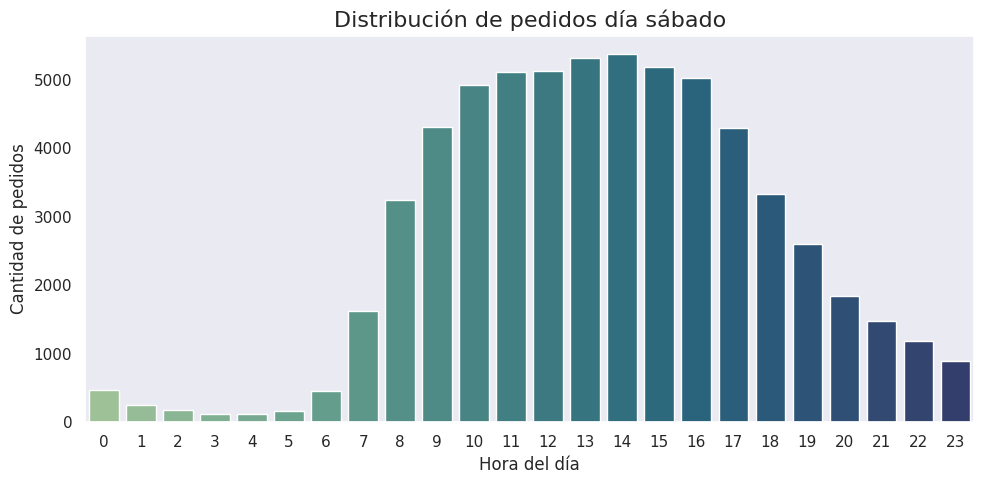

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set(style="dark")

# Crear el gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=orders_per_hour_sat.index, y=orders_per_hour_sat.values, palette="crest")

# Etiquetas y título
plt.title("Distribución de pedidos día sábado", fontsize=16)
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de pedidos")
plt.tight_layout()
plt.show()

In [ ]:
df_mier_sab = df_instacart_orders[df_instacart_orders['order_dow'].isin([3, 6])]
df_mier_sab  # Saca un df completo con los mismos indices solo con los sabados y miercoles

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
6,2511640,148233,40,3,8,2.0
11,102585,191558,18,6,16,8.0
14,2843219,74699,4,6,11,30.0
16,3109465,55090,19,3,15,9.0
...,...,...,...,...,...,...
478954,984024,47076,2,6,21,6.0
478956,640934,27104,9,3,10,6.0
478961,3006133,34561,7,6,10,30.0
478963,3270802,112087,2,3,13,6.0


In [ ]:
orders_per_hour_sat_wed = df_mier_sab['order_hour_of_day'].value_counts().sort_index()
orders_per_hour_sat_wed  # Pedidos por hora del día tanto para sábados como para miercoles

,count
order_hour_of_day,
0,837
1,469
2,283
3,226
4,226
5,331
6,1094
7,3351
8,6371


<ipython-input-148-f14fec0d7bdc>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_per_hour_sat_wed.index, y=orders_per_hour_sat_wed.values, palette="plasma")


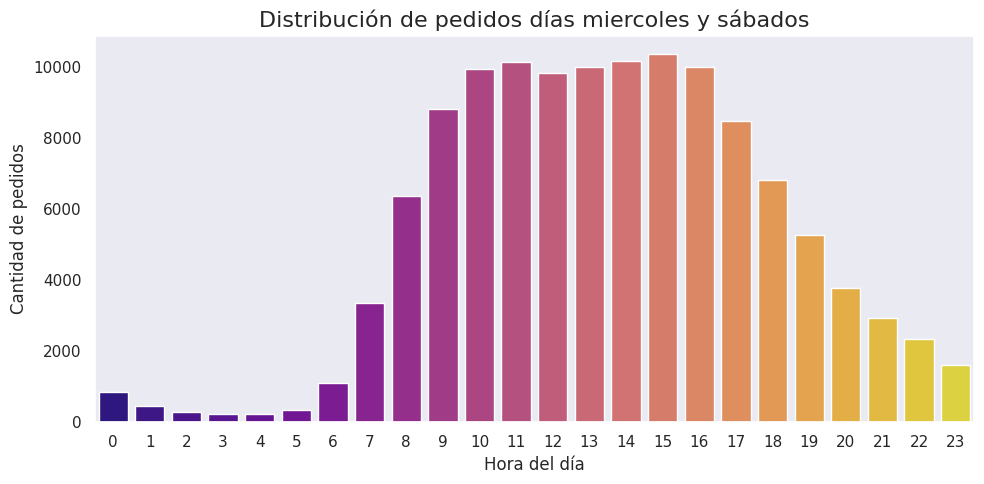

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set(style="dark")

# Crear el gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=orders_per_hour_sat_wed.index, y=orders_per_hour_sat_wed.values, palette="plasma")

# Etiquetas y título
plt.title("Distribución de pedidos días miercoles y sábados", fontsize=16)
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de pedidos")
plt.tight_layout()
plt.show()

<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

la hora del día en el que más hacen pedidos los miercoles es a las 10 am, los sábados a las 2 pm y haciendo el recuento de ambos días segun los datos combinados y sumados la hora en la que mas hacen pedidos es a las 3 pm.

Estas graficas noes muestran un comportamiento de compra muy similar en ambos días
</div>

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).

In [ ]:
orders_per_user = df_instacart_orders['user_id'].value_counts() # En df_instacart_orders almacena la ordenes hechas por la app, se cuenta cuantos pedidos a hecho cada usuario
orders_per_user

,count
user_id,
149605,28
193164,26
78375,25
134511,24
148162,24
...,...
73221,1
112002,1
82546,1


In [ ]:
df_instacart_orders['user_id'].value_counts().describe()

,count
count,157437.000000
mean,3.042182
std,2.746842
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,28.000000


In [ ]:
users_per_order = orders_per_user.value_counts() # Cantidad de usuarios que han hecho X cantidad de pedidos, es decir, 55357 usuarios han hecho solo un pedido por la app
users_per_order

,count
count,
1,55357
2,36508
3,21547
4,13498
5,8777
6,6012
7,4240
8,3019
9,2152


<ipython-input-152-583ad4916762>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=users_per_order.index, y=users_per_order.values, palette="inferno")


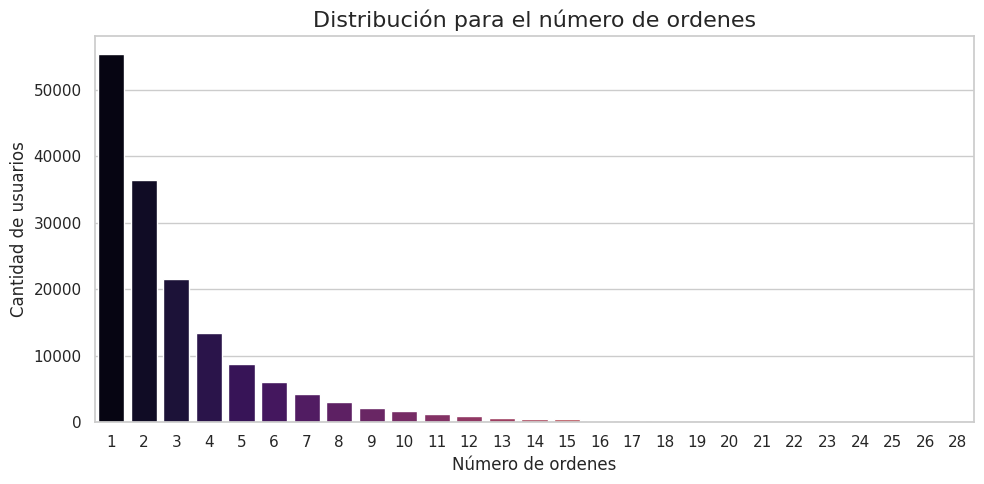

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set(style="whitegrid")

# Crear el gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=users_per_order.index, y=users_per_order.values, palette="inferno")

# Etiquetas y título
plt.title("Distribución para el número de ordenes", fontsize=16)
plt.xlabel("Número de ordenes")
plt.ylabel("Cantidad de usuarios")
plt.tight_layout()
plt.show()

<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

El usuario que más ordenes de pedido realiza es el usuario con id: 149605, realizando un conteo de la cantidad de veces que realizan cierta cantidad de pedidos nos muestra que la cantidad de usuarios que han hecho un solo pedido es la más alta con una cantidad de 55357 pedidos hechos una sola vez por usuario.
</div>

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [ ]:
df_order_products # En este dataframe se guardan la cantidad de ordenes realizadas al supermercado

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17,0
1,567889,1560,1,1
2,2261212,26683,1,1
3,491251,8670,35,1
4,2571142,1940,5,1
...,...,...,...,...
4545002,577211,15290,12,1
4545003,1219554,21914,9,0
4545004,692640,47766,4,1
4545005,319435,691,8,1


In [ ]:
product_counts = df_order_products['product_id'].value_counts().head(20) # Saca el conteo de veces que el mismo ID de producto es pedido en diferentes ordenes de pedido
product_counts

,count
product_id,
24852,66050
13176,53297
21137,37039
21903,33971
47209,29773
47766,24689
47626,21495
16797,20018
26209,19690


In [ ]:
# Paso 1: contar cuántas veces se pidió cada producto
product_counts = df_order_products['product_id'].value_counts().head(20)

# Paso 2: convertir ese resultado a DataFrame
top_20_products = product_counts.reset_index()
top_20_products.columns = ['product_id', 'order_count']

# Paso 3: unir con df_products para obtener el nombre del producto
"""
Hacemos un merge para agregar el nombre del producto al top 20, combinando
por 'product_id' y manteniendo todos los productos del top (left join).
"""
top_20_with_names = top_20_products.merge(df_products[['product_id', 'product_name']], on='product_id', how='left')

# Paso 4: mostrar el resultado ordenado
top_20_with_names

,product_id,order_count,product_name
0,24852,66050,BANANA
1,13176,53297,BAG OF ORGANIC BANANAS
2,21137,37039,ORGANIC STRAWBERRIES
3,21903,33971,ORGANIC BABY SPINACH
4,47209,29773,ORGANIC HASS AVOCADO
5,47766,24689,ORGANIC AVOCADO
6,47626,21495,LARGE LEMON
7,16797,20018,STRAWBERRIES
8,26209,19690,LIMES
9,27845,19600,ORGANIC WHOLE MILK


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

Para este análisis fue necesario ver en que df se almacenaba los datos de las ordenes pedidas, en el df_order_products encontramos esta información, al filtrarlo por product_id y hacer un conteo de valores se visualizan cuales son los productos más pedidos, luego de eso se imprime la información y se une con el df_products que contiene la info del nombre del producto, se unen usando en comun la columna priduct_id, eso nos muestra el resiltado, el producto más popular es la banana pedida una 66050 veces.
</div>

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [ ]:
df_order_products.sort_values(by='order_id') # df para la cantidad de ordenes

,order_id,product_id,add_to_cart_order,reordered
311805,4,46842,1,0
3977678,4,21351,6,1
1299531,4,32645,12,1
4107072,4,40285,9,1
1169276,4,27761,4,1
...,...,...,...,...
1505667,3421077,27966,1,0
719972,3421077,26940,3,0
4417991,3421077,45007,2,0
4000108,3421077,27845,4,0


In [ ]:
df_order_products[df_order_products['order_id'] == 61355].sort_values(by='add_to_cart_order') # Esto me saca un df que muestra los productos pedidos en una misma orden especificada
                                                                                              # La cantidad de articulos en cada orden se puede saber contando los valores en order_id

,order_id,product_id,add_to_cart_order,reordered
2897193,61355,47209,1,0
2652936,61355,34270,2,1
2187266,61355,41363,3,0
1628680,61355,28420,4,1
269840,61355,14233,5,0
...,...,...,...,...
3816634,61355,25659,999,0
4063159,61355,1087,999,0
4164200,61355,9484,999,0
4126014,61355,12440,999,0


In [ ]:
# Cada orden tiene un ID, cada ID se almacena como una orden a la que se le añaden productos y adicional el orden de añadidura al carrito
# Se cuentan los IDs de ordenes para ver exactamente cuantos productos hay por ID de orden
df_order_products['order_id'].value_counts() #La orden de pedido con mayor numero de productos es la orden con id 61355 con 127 productos

,count
order_id,
61355,127
3308010,115
2136777,108
171934,104
1959075,98
...,...
1933026,1
2528686,1
2273859,1


In [ ]:
# Acá se deja ver que la media en la serie df_order_products['order_id'].value_counts() es de 9.5, es decir los clientes suelen pedir esa cantidad de procudtos
# La mediana de 8 nos deja ver que el 50% de la gente ha pedido al menos 8 productos en sus pedidos
df_order_products['order_id'].value_counts().describe()

,count
count,450046.000000
mean,10.098983
std,7.540206
min,1.000000
25%,5.000000
50%,8.000000
75%,14.000000
max,127.000000


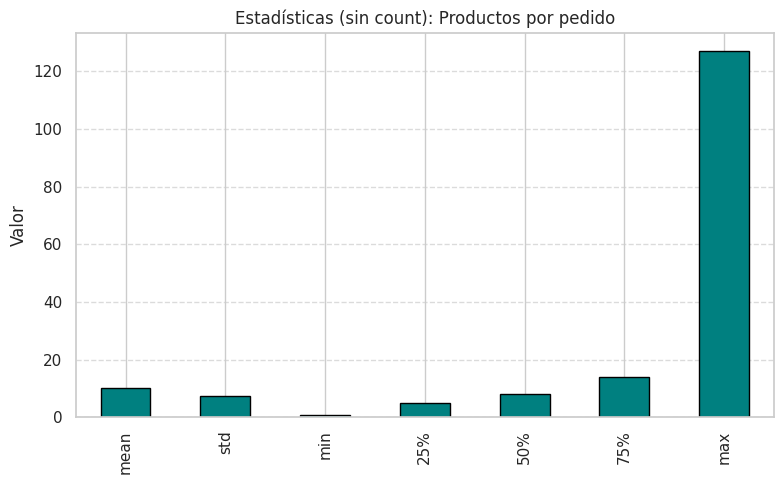

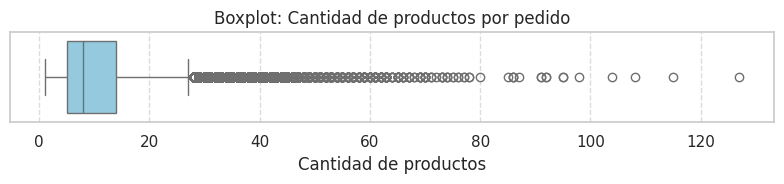

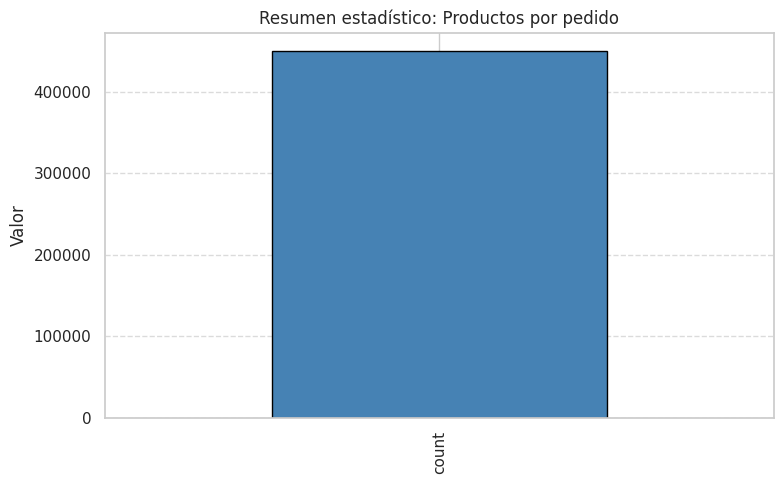

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponemos que ya tenés tu DataFrame cargado
order_counts = df_order_products['order_id'].value_counts()

# Obtenemos describe y lo excluimos el 'count'
order_stats1 = order_counts.describe().drop('count')
order_stats2 = order_counts.describe().drop(['mean', 'std', 'min', '25%', '50%', '75%', 'max'])


# 1. Gráfico de barras sin 'count'
plt.figure(figsize=(8, 5))
order_stats1.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Estadísticas (sin count): Productos por pedido')
plt.ylabel('Valor')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=order_counts, color='skyblue')
plt.title('Boxplot: Cantidad de productos por pedido')
plt.xlabel('Cantidad de productos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Gráfico de barras del describe() solo variable 'count'
plt.figure(figsize=(8, 5))
order_stats2.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Resumen estadístico: Productos por pedido')
plt.ylabel('Valor')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
orders_with_100_or_more_products = df_order_products['order_id'].value_counts()
big_orders = orders_with_100_or_more_products[orders_with_100_or_more_products > 100] # Solo hay 4 pedidos con mas de 100 productos, son pocos
big_orders.count()

np.int64(4)



<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

En promedio, los usuarios compran alrededor de 10 productos por pedido (mean ≈ 10.1). Sin embargo, la distribución muestra una alta variabilidad, con una desviación estándar de 7.54 productos, lo que indica que algunos pedidos contienen significativamente más o menos artículos que otros.

La mediana está en 8, lo cual sugiere que más de la mitad de los pedidos incluyen 8 productos o menos. Esto, junto con el percentil 75 en 14 y un máximo de 127, deja en evidencia una distribución sesgada hacia la derecha, con varios pedidos grandes que actúan como valores atípicos.

El boxplot confirma la presencia de outliers, lo cual es normal en este tipo de datos transaccionales: unos pocos clientes hacen compras grandes, pero la mayoría hace pedidos pequeños o medianos.
</div>

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [ ]:
df_order_products # En la columna 'reordered' indica si el producto fue reordenado

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17,0
1,567889,1560,1,1
2,2261212,26683,1,1
3,491251,8670,35,1
4,2571142,1940,5,1
...,...,...,...,...
4545002,577211,15290,12,1
4545003,1219554,21914,9,0
4545004,692640,47766,4,1
4545005,319435,691,8,1


In [ ]:
df_order_products[df_order_products['reordered'] == 1] # df solo de los items reordenados

,order_id,product_id,add_to_cart_order,reordered
1,567889,1560,1,1
2,2261212,26683,1,1
3,491251,8670,35,1
4,2571142,1940,5,1
5,2456893,21616,4,1
...,...,...,...,...
4544999,1622300,24852,1,1
4545000,1125324,40600,6,1
4545002,577211,15290,12,1
4545004,692640,47766,4,1


In [ ]:
# Conteo de veces que el mismo ID de producto se reordenó, los 20 primeros más ordenados en pedidos que han sido reordenados

products_most_reordered = df_order_products[df_order_products['reordered'] == 1]['product_id'].value_counts().head(20) # serie de valores
products_most_reordered


,count
product_id,
24852,55763
13176,44450
21137,28639
21903,26233
47209,23629
47766,18743
27845,16251
47626,15044
27966,14748


In [ ]:
top_20_reordered = products_most_reordered.reset_index()
top_20_reordered.columns = ['product_id', 'reordered_count'] # Se organiza la serie y se le da formato de df y se cambia el nombre de las columnas
top_20_reordered


,product_id,reordered_count
0,24852,55763
1,13176,44450
2,21137,28639
3,21903,26233
4,47209,23629
5,47766,18743
6,27845,16251
7,47626,15044
8,27966,14748
9,16797,13945


In [ ]:
 # Se unen los dos df con la columna comun 'product_id'
 # Se visualizan los 20 productos más pedidos que han sido reordenados
top_20_reordered_merged = top_20_reordered.merge(df_products[['product_id', 'product_name']], on='product_id', how='left')
top_20_reordered_merged

,product_id,reordered_count,product_name
0,24852,55763,BANANA
1,13176,44450,BAG OF ORGANIC BANANAS
2,21137,28639,ORGANIC STRAWBERRIES
3,21903,26233,ORGANIC BABY SPINACH
4,47209,23629,ORGANIC HASS AVOCADO
5,47766,18743,ORGANIC AVOCADO
6,27845,16251,ORGANIC WHOLE MILK
7,47626,15044,LARGE LEMON
8,27966,14748,ORGANIC RASPBERRIES
9,16797,13945,STRAWBERRIES


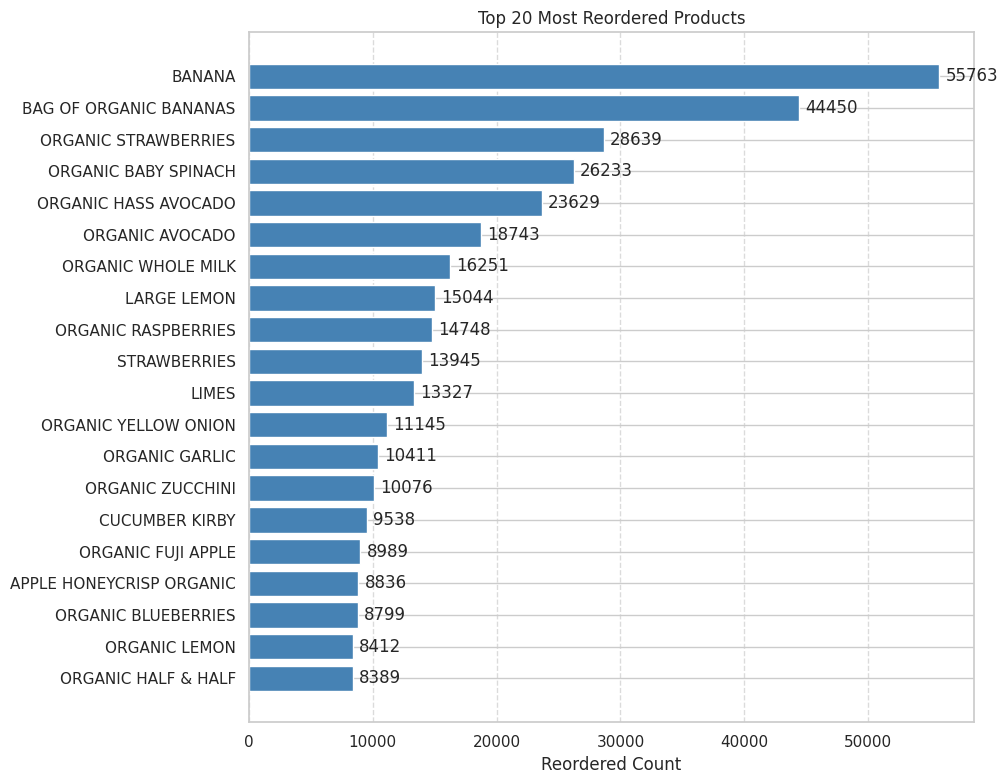

In [ ]:
import matplotlib.pyplot as plt

# Gráfico para df top_20_reordered_merged
# Ordenar de mayor a menor para que la barra más alta quede arriba
df_sorted = top_20_reordered_merged.sort_values(by='reordered_count', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df_sorted['product_name'], df_sorted['reordered_count'], color='steelblue') # gráfico de barras horizontales: y=categorías, x=valores
plt.xlabel('Reordered Count')
plt.title('Top 20 Most Reordered Products')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar valores al lado de las barras
for index, value in enumerate(df_sorted['reordered_count']):
    plt.text(value + 500, index, str(value), va='center')

plt.show()


<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

El análisis de los productos más reordenados revela una clara preferencia de los clientes por frutas y productos orgánicos. El producto más recurrente es BANANA (ID: 24852), con más de 55,000 reordenes, seguido por otros productos frescos como BAG OF ORGANIC BANANAS, ORGANIC STRAWBERRIES, y ORGANIC BABY SPINACH.

Esta tendencia sugiere que los consumidores tienden a reponer regularmente alimentos perecederos y saludables, lo cual puede deberse tanto a su alta frecuencia de consumo como a su corta vida útil. La presencia predominante de artículos etiquetados como “orgánicos” también evidencia una preferencia por productos percibidos como más saludables o sostenibles.

Desde el punto de vista comercial, esta información es clave para:

Optimizar el inventario y la reposición de productos frescos.

Focalizar campañas de fidelización y promociones en estos productos de alta rotación.

Reforzar el surtido de productos saludables y orgánicos.
</div>

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir? / Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos)?


In [ ]:
"""
.agg() significa "aggregate", y lo que hace es permitirte aplicar una o más funciones estadísticas
(como: sum, mean, count, min, max, etc.) a uno o varios grupos de un DataFrame.
Lo usás junto con groupby() para resumir o condensar datos por grupo.
"""

# Agrupamos por product_id y calculamos:
# - total de veces que se pidió (conteo)
# - total de veces que fue reordenado (suma de reordered = 1)
reorder_stats = df_order_products.groupby('product_id').agg(
    total_orders=('reordered', 'count'),
    total_reorders=('reordered', 'sum')
).reset_index()

# Calculamos la tasa de repetición: total reorders dividido entre total pedidos
reorder_stats['reorder_rate'] = reorder_stats['total_reorders'] / reorder_stats['total_orders']

# Mostramos las primeras filas
reorder_stats.head()

,product_id,total_orders,total_reorders,reorder_rate
0,1,280,158,0.564286
1,2,11,0,0.000000
2,3,42,31,0.738095
3,4,49,25,0.510204
4,7,2,1,0.500000


In [ ]:
# Unimos el dataframe de tasas con los nombres de los productos desde df_products
# Para ello usamos un merge por product_id
df_reorder_with_names = reorder_stats.merge(df_products, on='product_id', how='left')

# Mostramos las columnas relevantes
df_reorder_with_names = df_reorder_with_names[['product_id', 'product_name', 'reorder_rate']]
df_reorder_with_names.head()

top_reordered = df_reorder_with_names.sort_values(by='reorder_rate', ascending=False).head(20)
top_reordered

,product_id,product_name,reorder_rate
28108,30644,ORGANIC FRENCH ROAST,1.0
7340,8054,BISSLI SMOKEY WHEAT SNACKS,1.0
28114,30650,MUSHROOM LOVER'S VEGGIE BURGERS,1.0
41002,44747,FROZEN ORGANIC BLACKBERRIES,1.0
40998,44743,REAL ZERO COLA,1.0
32921,35897,HAM HOCK,1.0
32861,35834,BULGARIAN ORGANIC YOGURT,1.0
2684,2939,CHEDDAR CRUNCHIN' CRACKERS,1.0
20357,22209,TEMPLES EARL GRAY STRONG TEA,1.0
20361,22213,2% REDUCED FAT CHOCOLATE MILK,1.0


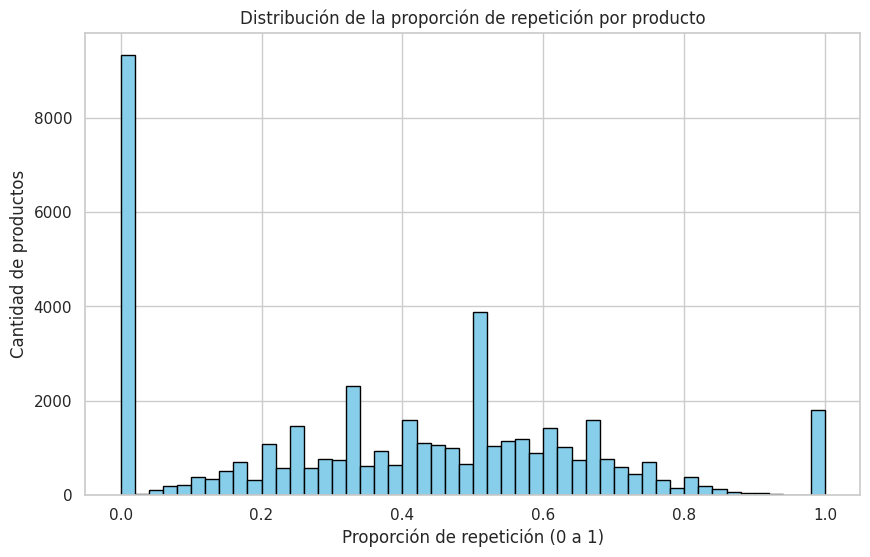

In [ ]:
import matplotlib.pyplot as plt

# Creamos un histograma para visualizar la distribución de las proporciones de repetición
plt.figure(figsize=(10, 6))
plt.hist(reorder_stats['reorder_rate'], bins=50, color='skyblue', edgecolor='black')

# Título y etiquetas
plt.title('Distribución de la proporción de repetición por producto')
plt.xlabel('Proporción de repetición (0 a 1)')
plt.ylabel('Cantidad de productos')
plt.grid(True)
plt.show()

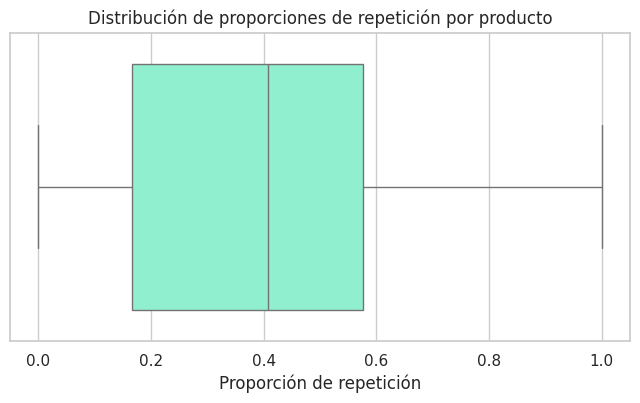

In [ ]:
import seaborn as sns

# Creamos un diagrama de caja para ver la dispersión y valores atípicos en la proporción de repetición
plt.figure(figsize=(8, 4))
sns.boxplot(data=reorder_stats, x='reorder_rate', color='aquamarine')

# Título y etiqueta
plt.title('Distribución de proporciones de repetición por producto')
plt.xlabel('Proporción de repetición')
plt.show()

<ipython-input-82-962ca04d11fd>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


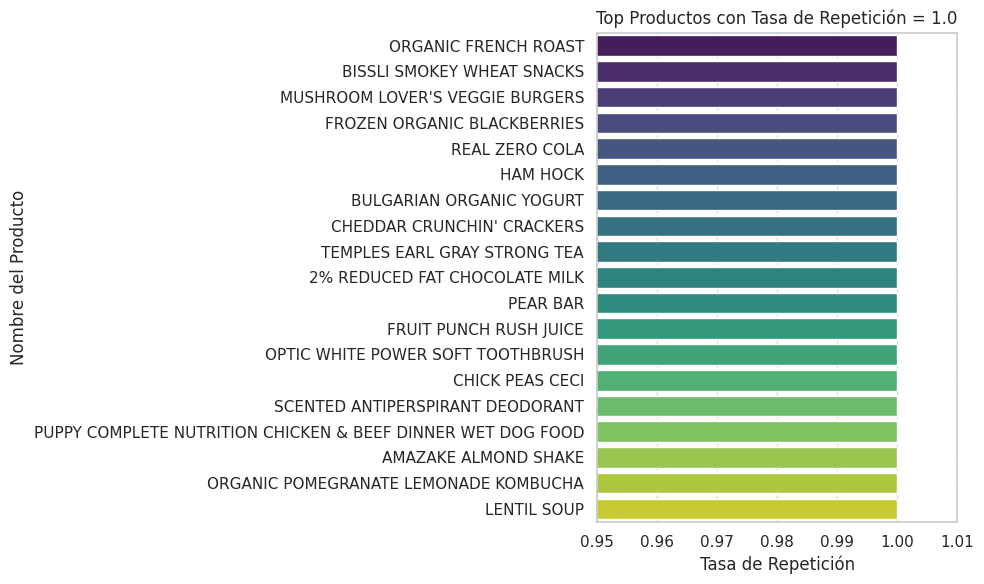

In [ ]:
# Gráfico de barras horizontales para los productos con mayor tasa de repetición
# Objetivo: destacar los productos más reordenados por nombre y su tasa máxima (1.0)

plt.figure(figsize=(10, 6))
sns.barplot(
    y='product_name',
    x='reorder_rate',
    data=top_reordered,
    palette='viridis'
)

plt.title('Top Productos con Tasa de Repetición = 1.0')
plt.xlabel('Tasa de Repetición')
plt.ylabel('Nombre del Producto')
plt.xlim(0.95, 1.01)  # Ajuste visual para que no corte las barras en 1.0
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Este filtrado me muestra el df con el número total de ordenes y reordenes y su proporción
# Se grafica para ver la proporción ordenes de algunos productos

df_reorder_with_names2 = reorder_stats.merge(df_products, on='product_id', how='left').drop(['aisle_id','department_id'], axis=1)
df_reorder_with_names2.head()

,product_id,total_orders,total_reorders,reorder_rate,product_name
0,1,280,158,0.564286,CHOCOLATE SANDWICH COOKIES
1,2,11,0,0.000000,ALL-SEASONS SALT
2,3,42,31,0.738095,ROBUST GOLDEN UNSWEETENED OOLONG TEA
3,4,49,25,0.510204,SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...
4,7,2,1,0.500000,PURE COCONUT WATER WITH ORANGE


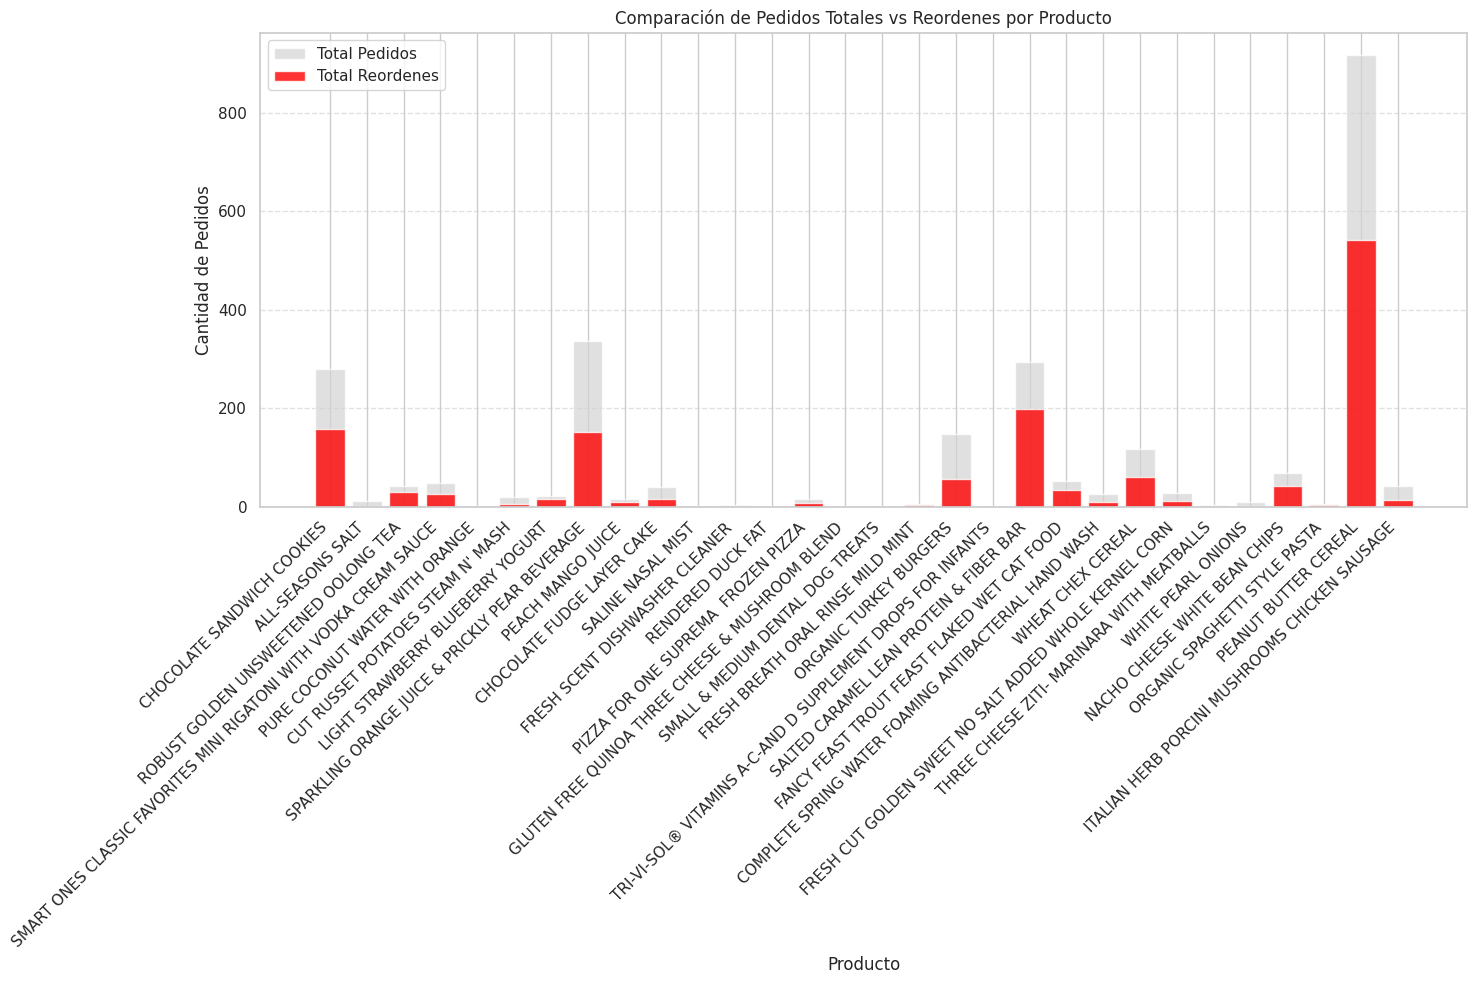

In [ ]:
# Importar librerías necesarias
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos los primeros productos para que el gráfico sea legible (ajustable)
df_subset = df_reorder_with_names2.head(30)

# Crear gráfico de barras agrupadas: comparación entre total_orders y total_reorders
plt.figure(figsize=(15, 10))

# Barras de total_orders (en gris claro)
plt.bar(df_subset['product_name'], df_subset['total_orders'], label='Total Pedidos', alpha=0.7, color='lightgray')

# Barras de total_reorders (en rojo encima)
plt.bar(df_subset['product_name'], df_subset['total_reorders'], label='Total Reordenes', alpha=0.8, color='red')

# Títulos y etiquetas
plt.title('Comparación de Pedidos Totales vs Reordenes por Producto')
plt.xlabel('Producto')
plt.ylabel('Cantidad de Pedidos')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()



<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

La mayoría de los productos tienen una tasa de repetición baja o nula, lo que indica que muchos de ellos se compran una sola vez y no vuelven a ser pedidos. Sin embargo, existe un grupo considerable de productos con una alta tasa de repetición, algunos alcanzando el 100%, lo cual sugiere que esos productos son altamente valorados y recurrentemente comprados por los usuarios.

La distribución no es uniforme: se observa una concentración fuerte en torno a valores bajos (cercanos a 0), y una segunda agrupación en 1.0, representando productos que siempre se reordenan. Esto se evidencia en el histograma, con picos en ambos extremos, y en el boxplot, que muestra una mediana en torno a 0.4, indicando que más de la mitad de los productos tienen una repetición moderada o baja.

Esto sugiere que si se busca identificar productos “clave” o de alta fidelidad por parte del cliente, hay que enfocarse en ese grupo con reorder_rate cercano a 1. Por otro lado, muchos productos podrían no estar generando fidelidad o simplemente son comprados por única vez (por ejemplo, por prueba o por necesidad puntual).
</div>


### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [ ]:
merged = df_order_products.merge(df_instacart_orders[['order_id', 'user_id']], on='order_id')

In [ ]:
user_reorder_stats = merged.groupby('user_id').agg(
    total_products=('product_id', 'count'),
    reordered_products=('reordered', 'sum')
)

user_reorder_stats['reorder_ratio'] = user_reorder_stats['reordered_products'] / user_reorder_stats['total_products'] # Proporción
user_reorder_stats

,total_products,reordered_products,reorder_ratio
user_id,,,
2,26,1,0.038462
4,2,0,0.000000
5,12,8,0.666667
6,4,0,0.000000
7,14,13,0.928571
...,...,...,...
206203,27,6,0.222222
206206,21,15,0.714286
206207,46,41,0.891304



<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

La proporción de productos previamente comprados por los clientes ("reorder ratio") varía significativamente entre usuarios. Esto indica que hay perfiles de compra muy distintos: algunos usuarios tienden a repetir sus productos con alta frecuencia (reorder ratio cercano a 1), mientras que otros exploran productos nuevos o no tienen hábitos de repetición marcados (reorder ratio cercano a 0).

Este comportamiento sugiere que, si se quisiera optimizar un sistema de recomendaciones o de inventario, sería clave segmentar a los usuarios según su propensión a repetir compras. Además, el hecho de que muchos usuarios tengan un ratio bajo indica una oportunidad para estrategias de fidelización de productos.
</div>

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [ ]:
first_added = df_order_products[df_order_products['add_to_cart_order'] == 1]
first_added

,order_id,product_id,add_to_cart_order,reordered
1,567889,1560,1,1
2,2261212,26683,1,1
14,1961225,37553,1,1
16,639939,10017,1,1
23,750040,8518,1,0
...,...,...,...,...
4544978,1759009,46175,1,0
4544989,115427,20842,1,1
4544990,2049780,28576,1,1
4544997,2300092,10017,1,0


In [ ]:
top_first_products = first_added['product_id'].value_counts().head(20)
top_first_products

,count
product_id,
24852,15562
13176,11026
27845,4363
21137,3946
47209,3390
21903,3336
47766,3044
19660,2336
16797,2308


In [ ]:
top_first_products = top_first_products.reset_index()
top_first_products.columns = ['product_id', 'count']

top_first_products = top_first_products.merge(df_products[['product_id', 'product_name']], on='product_id')
top_first_products

,product_id,count,product_name
0,24852,15562,BANANA
1,13176,11026,BAG OF ORGANIC BANANAS
2,27845,4363,ORGANIC WHOLE MILK
3,21137,3946,ORGANIC STRAWBERRIES
4,47209,3390,ORGANIC HASS AVOCADO
5,21903,3336,ORGANIC BABY SPINACH
6,47766,3044,ORGANIC AVOCADO
7,19660,2336,SPRING WATER
8,16797,2308,STRAWBERRIES
9,27966,2024,ORGANIC RASPBERRIES




<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>

El análisis muestra que los productos que los clientes colocan primero en sus carritos tienden a ser alimentos frescos, esenciales y frecuentemente consumidos, destacándose especialmente:

Frutas frescas como bananas, fresas y limones.

Productos orgánicos, en particular leche, palta (aguacate), espinaca y cebolla amarilla.

Bebidas básicas, incluyendo agua natural, agua con gas y soda.

El producto más agregado en primera posición es, por amplio margen, la banana (ID: 24852), seguida por su versión orgánica. Esto refleja hábitos de consumo rutinario donde ciertos artículos se consideran prioritarios, tal vez porque son percibidos como “infaltables” en cada compra.

En términos comerciales, estos productos representan puntos de entrada al carrito de compra, y son ideales para:

Estrategias de upselling (ej: promociones relacionadas).

Cross-selling de productos complementarios (ej: bananas + leche + granola).

Diseño de interfaces donde estos productos se sugieran desde el inicio.

En resumen: los primeros artículos en el carrito reflejan hábitos estables y predecibles, con una fuerte preferencia por lo saludable, lo orgánico y lo esencial.
</div>

### Conclusion general del proyecto:




<div style="background-color: #e0ffff; padding: 10px; border-radius: 5px;">
  <strong>Escribe aquí tus conclusiones</strong>
Este proyecto demuestra cómo, mediante un análisis estructurado y completo, es posible transformar datos crudos en información accionable. El uso adecuado de técnicas de limpieza, manipulación, análisis estadístico y visualización permitió extraer patrones de comportamiento concretos y detectar oportunidades claras para la optimización de la experiencia de compra en plataformas como Instacart.

El dominio de herramientas como pandas, matplotlib y seaborn, así como el uso de metodologías robustas de EDA, no solo facilitó el entendimiento profundo del dataset, sino que también dejó la puerta abierta para futuros análisis predictivos o modelos de recomendación.

En resumen: se pasó de datos dispersos a conocimiento estructurado. Y de ahí, a una base sólida para tomar decisiones inteligentes.

Además, este proceso reafirma la importancia de un enfoque meticuloso y sistemático en el manejo de grandes volúmenes de datos, especialmente en entornos dinámicos como el comercio electrónico. La capacidad de interpretar correctamente la información no solo impulsa mejoras operativas, sino que también fomenta una cultura de toma de decisiones basada en evidencia, esencial para mantener la competitividad en mercados altamente demandantes y en constante evolución. Este proyecto sienta un precedente claro sobre cómo la integración de análisis rigurosos y tecnología puede transformar datos en ventajas estratégicas sostenibles.
</div>